# Project 3: Sales Forecasting
## Notebook 2: SARIMA — Classical Time Series Forecasting

SARIMA = Seasonal AutoRegressive Integrated Moving Average

**Parameters:**
- p = AR order (how many past values to use)
- d = differencing order (to make stationary)
- q = MA order (how many past errors to use)
- P, D, Q, s = seasonal equivalents (s=12 for monthly data)

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import itertools

plt.rcParams['figure.dpi'] = 120

BASE      = Path(r'C:\Users\Administrator\SalesForecast')
PROC_DIR  = BASE / 'data' / 'processed'
MODEL_DIR = BASE / 'models'
FIG_DIR   = BASE / 'reports' / 'figures'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Train/Test Split

In [2]:
monthly = pd.read_csv(PROC_DIR / 'monthly_sales.csv', index_col=0, parse_dates=True)
monthly = monthly.squeeze()

# Hold out last 12 months for testing
TEST_MONTHS = 12
train = monthly[:-TEST_MONTHS]
test  = monthly[-TEST_MONTHS:]

print(f'Total:  {len(monthly)} months')
print(f'Train:  {len(train)} months ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test:   {len(test)} months  ({test.index[0].date()} to {test.index[-1].date()})')

Total:  48 months
Train:  36 months (2014-01-01 to 2016-12-01)
Test:   12 months  (2017-01-01 to 2017-12-01)


## 2. Grid Search for Best SARIMA Parameters

We test combinations of (p,d,q)(P,D,Q) and pick the one with the lowest AIC.

In [11]:
import pandas as pd

df = pd.read_csv(
    r"C:/Users/Administrator/Downloads/archive (4)/Sample - Superstore.csv",
    encoding="latin-1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.set_index('Order Date')

monthly = df['Sales'].resample('MS').sum()

In [13]:
monthly = monthly.asfreq('MS')

In [14]:
def find_best_sarima(series, p_range=(0,2), d=1, q_range=(0,2),
                     P_range=(0,1), D=1, Q_range=(0,1), s=12):
    best_aic = np.inf
    best_order = None
    results_list = []

    for p, q, P, Q in itertools.product(
        range(*p_range), range(*q_range),
        range(*P_range), range(*Q_range)
    ):
        try:
            model = SARIMAX(series,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            fitted = model.fit(disp=False)
            results_list.append({'p':p,'d':d,'q':q,'P':P,'D':D,'Q':Q,'AIC':fitted.aic})
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
                best_seasonal = (P, D, Q, s)
        except:
            continue

    print(f'Best order:    {best_order}')
    print(f'Best seasonal: {best_seasonal}')
    print(f'Best AIC:      {best_aic:.2f}')
    return best_order, best_seasonal, pd.DataFrame(results_list)

print('Running grid search (takes ~1-2 minutes)...')
best_order, best_seasonal, aic_df = find_best_sarima(train)
print('\nTop 5 models by AIC:')
print(aic_df.sort_values('AIC').head().to_string(index=False))

Running grid search (takes ~1-2 minutes)...
Best order:    (0, 1, 1)
Best seasonal: (0, 1, 0, 12)
Best AIC:      455.27

Top 5 models by AIC:
 p  d  q  P  D  Q        AIC
 0  1  1  0  1  0 455.268898
 1  1  1  0  1  0 456.085589
 1  1  0  0  1  0 483.410158
 0  1  0  0  1  0 489.546110


c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\L

## 3. Fit Best Model

In [15]:
sarima = SARIMAX(train,
                order=best_order,
                seasonal_order=best_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         Total Sales   No. Observations:                   36
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -225.634
Date:                             Sat, 13 Jun 2026   AIC                            455.269
Time:                                     13:42:29   BIC                            457.358
Sample:                                 01-01-2014   HQIC                           455.722
                                      - 12-01-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5942      0.197     -3.011      0.003      -0.981      -0.207
sigma2      1.269e+08   6.4

c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Administrator\SalesForecastingDashboard\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 4. Forecast & Evaluate

In [16]:
# Forecast on test period
forecast = sarima_fit.get_forecast(steps=TEST_MONTHS)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)  # 95% confidence interval

# Metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mae  = mean_absolute_error(test, forecast_mean)
map_ = mape(test.values, forecast_mean.values)

print('=== SARIMA Test Metrics ===')
print(f'  MAPE: {map_:.2f}%')
print(f'  RMSE: ${rmse:,.0f}')
print(f'  MAE:  ${mae:,.0f}')

=== SARIMA Test Metrics ===
  MAPE: 28.92%
  RMSE: $16,677
  MAE:  $13,853


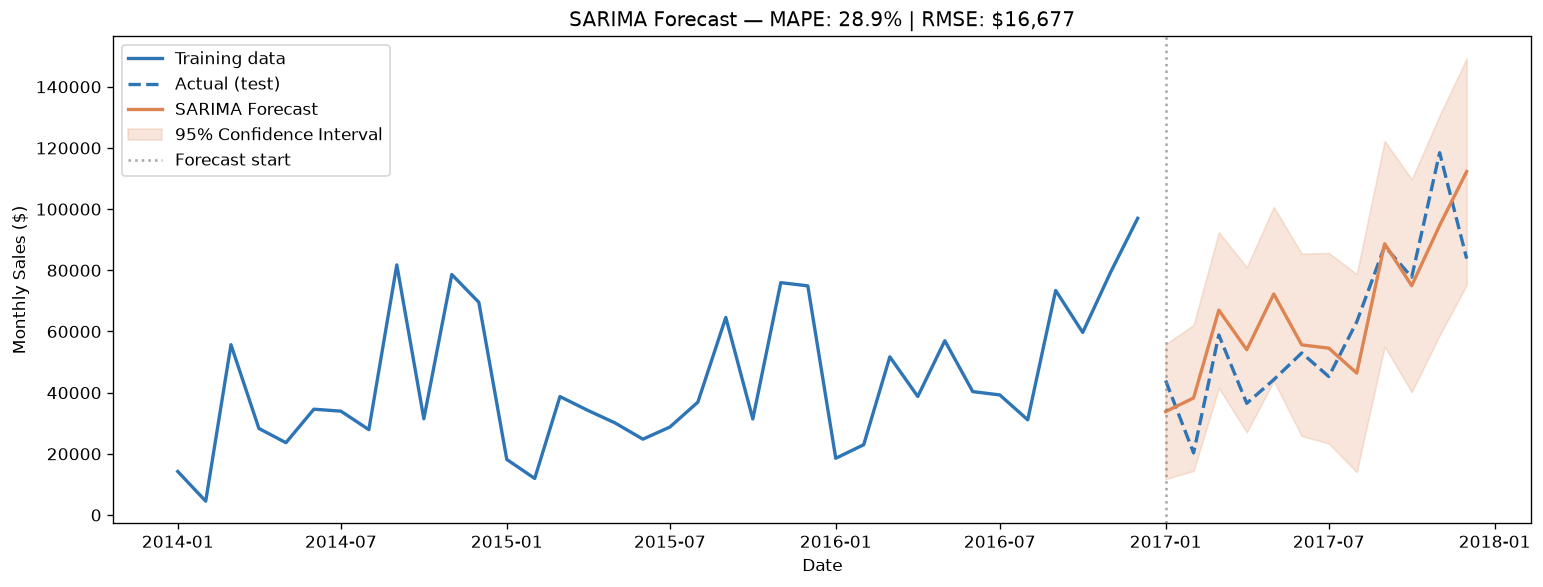

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index, train.values, color='#2E75B6', lw=2, label='Training data')
ax.plot(test.index,  test.values,  color='#2E75B6', lw=2, linestyle='--', label='Actual (test)')
ax.plot(forecast_mean.index, forecast_mean.values, color='#DD8452', lw=2, label='SARIMA Forecast')
ax.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                alpha=0.20, color='#DD8452', label='95% Confidence Interval')

ax.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7, label='Forecast start')
ax.set(title=f'SARIMA Forecast — MAPE: {map_:.1f}% | RMSE: ${rmse:,.0f}',
       xlabel='Date', ylabel='Monthly Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06_sarima_forecast.png', bbox_inches='tight')
plt.show()

## 5. Future Forecast (12 months beyond data)

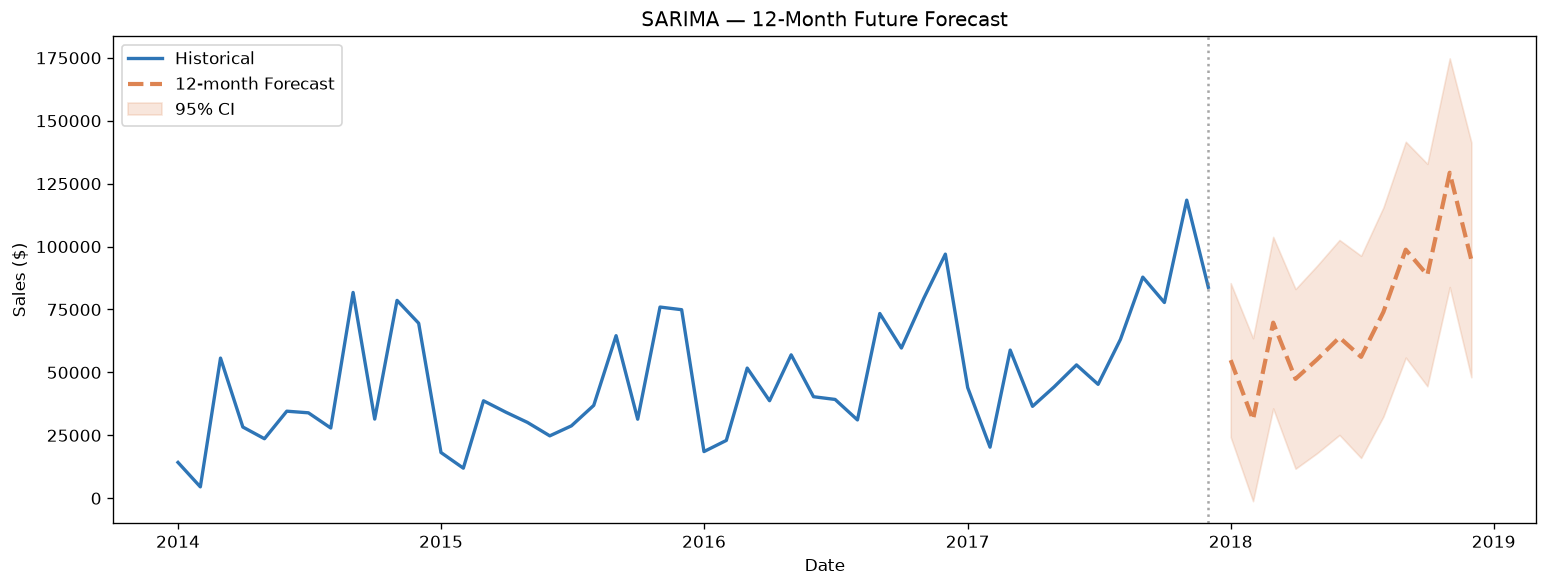

In [19]:
# Refit on ALL data for future forecasting
sarima_full = SARIMAX(monthly,
                      order=best_order,
                      seasonal_order=best_seasonal,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

future_fc    = sarima_full.get_forecast(steps=12)
future_mean  = future_fc.predicted_mean
future_ci    = future_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, color='#2E75B6', lw=2, label='Historical')
ax.plot(future_mean.index, future_mean.values, color='#DD8452', lw=2.5,
        linestyle='--', label='12-month Forecast')
ax.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1],
                alpha=0.20, color='#DD8452', label='95% CI')
ax.axvline(monthly.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set(title='SARIMA — 12-Month Future Forecast', xlabel='Date', ylabel='Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '07_sarima_future.png', bbox_inches='tight')
plt.show()

## 6. Save Model & Results

In [20]:
joblib.dump(sarima_full, MODEL_DIR / 'sarima_model.pkl')
joblib.dump({'order': best_order, 'seasonal_order': best_seasonal}, MODEL_DIR / 'sarima_params.pkl')

# Save metrics for comparison notebook
import json
sarima_metrics = {'model':'SARIMA','mape':round(map_,2),'rmse':round(rmse,0),'mae':round(mae,0)}
with open(MODEL_DIR / 'sarima_metrics.json','w') as f:
    json.dump(sarima_metrics, f)

print('Saved: models/sarima_model.pkl')
print('Next: open 03_prophet.ipynb')

Saved: models/sarima_model.pkl
Next: open 03_prophet.ipynb
